# 1.Twitter GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [1]:
!pip install shap

In [11]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))   # chỉnh path tới graph_lib.py

from graph_lib import (
    UNWEIGHTED_TABLE,
    compute_relation_weights,        # <-- THÊM dòng này
    build_homophily_edges, build_similarity_knn_edges,
    compute_centrality_features, compute_node2vec_embeddings,
    evaluate_predictions, shap_summary,
    visualize_subgraph_sample,  
    train_eval_variant
)
import pandas as pd
from xgboost import XGBClassifier

PLATFORM = "Twitter"
SEEDS = [42, 123, 2024, 7, 99]
ML_DIR = Path("../../data_preprocess/processed_data/ml_data")
GRAPH_DIR = Path("../../data_preprocess/processed_data/graph_data")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NUMERIC_SIM_COLS = ["followers", "account_age_days", "content_length", "num_hashtags"]

attrs_df = pd.read_csv(GRAPH_DIR / f"{PLATFORM.lower()}_graph.csv")

attrs_df = attrs_df.sample(frac=0.30, random_state=42).reset_index(drop=True)
SAMPLED_IDS = set(attrs_df["post_id"])
print(f"[INFO] attrs_df reduced to 30%: {len(attrs_df)} rows")


[INFO] attrs_df reduced to 30%: 13403 rows


Cell 1 — Build graph

In [12]:
graph_cache = {}

for seed in SEEDS:
    print(f"Building graphs for seed {seed}...")

    train_meta = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_train_seed{seed}.csv")
    test_meta  = pd.read_csv(ML_DIR / f"{PLATFORM.lower()}_test_seed{seed}.csv")

    # ── Filter to 30% sampled post_ids ────────────────────────────
    train_meta = train_meta[train_meta["post_id"].isin(SAMPLED_IDS)].reset_index(drop=True)
    test_meta  = test_meta[test_meta["post_id"].isin(SAMPLED_IDS)].reset_index(drop=True)
    print(f"  [seed {seed}] After 30% sample -> train: {len(train_meta)} | test: {len(test_meta)}")
    # ──────────────────────────────────────────────────────────────

    train_ids = set(train_meta["post_id"])
    test_ids  = set(test_meta["post_id"])
    all_ids   = list(train_ids | test_ids)

    nodes_df = attrs_df[attrs_df["post_id"].isin(all_ids)].copy()
    train_attrs = attrs_df[attrs_df["post_id"].isin(train_ids)].copy()

    weight_table, mi_scores = compute_relation_weights(train_attrs, label_col="popularity", seed=seed)
    print(f"  [seed {seed}] data-driven weights: {dict((k, round(v,3)) for k,v in weight_table.items())}")

    edges_uw = build_homophily_edges(nodes_df, train_ids, UNWEIGHTED_TABLE)
    feat_uw, _ = compute_centrality_features(edges_uw, all_ids, betweenness_k=300, seed=seed)

    edges_knn = build_similarity_knn_edges(nodes_df, train_ids, NUMERIC_SIM_COLS, k=5)
    feat_knn, _ = compute_centrality_features(edges_knn, all_ids, betweenness_k=300, seed=seed)

    edges_dd = build_homophily_edges(nodes_df, train_ids, weight_table)
    feat_dd, G_dd = compute_centrality_features(edges_dd, all_ids, betweenness_k=300, seed=seed)

    emb_df = compute_node2vec_embeddings(G_dd, dimensions=64, walk_length=20, num_walks=20, workers=4, seed=seed)

    graph_cache[seed] = {
        "train_meta": train_meta,
        "test_meta": test_meta,
        "weight_table": weight_table,
        "feature_sets": {
            "no_graph": None,
            "unweighted_homophily": feat_uw,
            "similarity_knn": feat_knn,
            "data_driven_homophily": feat_dd,
        },
        "emb_df": emb_df,
        "graph_object": G_dd,
    }
    print(f"  done. edges -> unweighted: {len(edges_uw)} | knn: {len(edges_knn)} | data-driven: {len(edges_dd)}")

weight_records = []
for seed, c in graph_cache.items():
    row = {"platform": PLATFORM, "seed": seed}
    row.update(c["weight_table"])
    weight_records.append(row)
pd.DataFrame(weight_records).to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_relation_weights.csv", index=False)
print("\nAll graphs cached. Relation weights saved to CSV.")

Building graphs for seed 42...
  [seed 42] After 30% sample -> train: 10767 | test: 2636
  [seed 42] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.5), 'same_language': np.float64(0.501), 'same_media_type': np.float64(0.501), 'same_toxicity_bin': np.float64(0.5)}


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  done. edges -> unweighted: 64601 | knn: 49585 | data-driven: 64601
Building graphs for seed 123...
  [seed 123] After 30% sample -> train: 10739 | test: 2664
  [seed 123] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.501), 'same_topic': np.float64(0.5), 'same_language': np.float64(0.502), 'same_media_type': np.float64(0.501), 'same_toxicity_bin': np.float64(0.5)}


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  done. edges -> unweighted: 64492 | knn: 49742 | data-driven: 64492
Building graphs for seed 2024...
  [seed 2024] After 30% sample -> train: 10674 | test: 2729
  [seed 2024] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.5), 'same_language': np.float64(0.501), 'same_media_type': np.float64(0.501), 'same_toxicity_bin': np.float64(0.501)}


...

  done. edges -> unweighted: 64347 | knn: 49979 | data-driven: 64347
Building graphs for seed 7...
  [seed 7] After 30% sample -> train: 10719 | test: 2684
  [seed 7] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.5), 'same_language': np.float64(0.5), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.5)}


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  done. edges -> unweighted: 64407 | knn: 49760 | data-driven: 64407
Building graphs for seed 99...
  [seed 99] After 30% sample -> train: 10680 | test: 2723
  [seed 99] data-driven weights: {'same_author': np.float64(2.0), 'same_location': np.float64(0.5), 'same_topic': np.float64(0.501), 'same_language': np.float64(0.501), 'same_media_type': np.float64(0.5), 'same_toxicity_bin': np.float64(0.5)}


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


  done. edges -> unweighted: 64397 | knn: 49815 | data-driven: 64397

All graphs cached. Relation weights saved to CSV.


  OK: không có cạnh test-test trong subsample này.


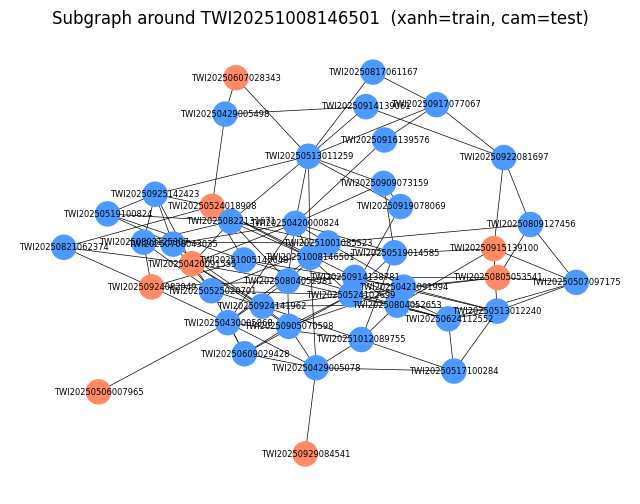

In [13]:
G_check = graph_cache[42]["graph_object"]
train_ids_42 = set(graph_cache[42]["train_meta"]["post_id"])
visualize_subgraph_sample(G_check, train_ids_42, save_path=RESULTS_DIR / "subgraph_check_seed42.png")

  OK: không có cạnh test-test trong subsample này.


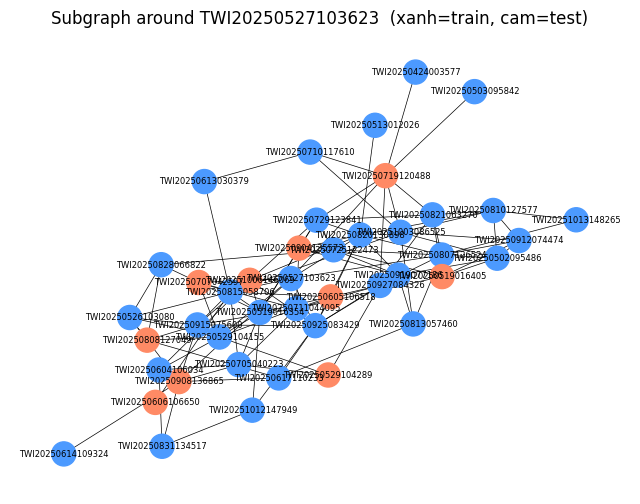

In [14]:
G_check = graph_cache[123]["graph_object"]
train_ids_123 = set(graph_cache[123]["train_meta"]["post_id"])
visualize_subgraph_sample(G_check, train_ids_123, save_path=RESULTS_DIR / "subgraph_check_seed123.png")

  OK: không có cạnh test-test trong subsample này.


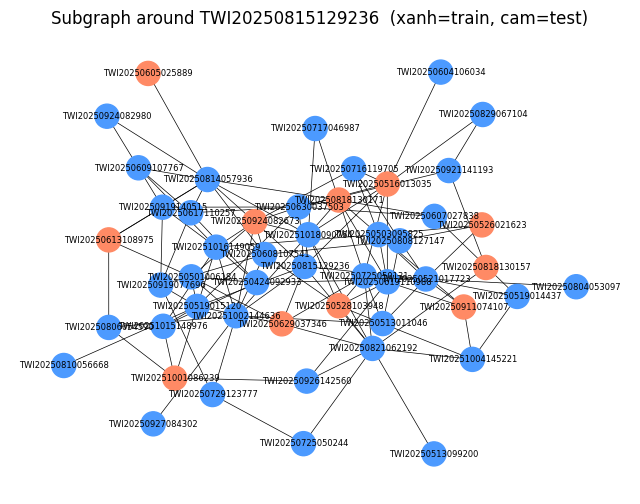

In [15]:
G_check = graph_cache[2024]["graph_object"]
train_ids_2024 = set(graph_cache[2024]["train_meta"]["post_id"])
visualize_subgraph_sample(G_check, train_ids_2024, save_path=RESULTS_DIR / "subgraph_check_seed2024.png")

  OK: không có cạnh test-test trong subsample này.


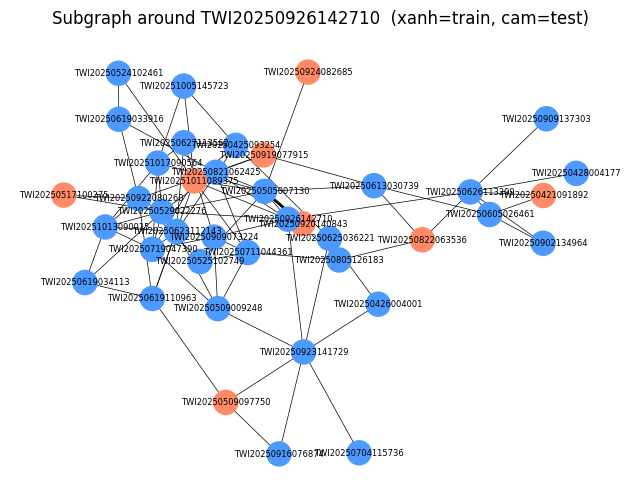

In [16]:
G_check = graph_cache[7]["graph_object"]
train_ids_7 = set(graph_cache[7]["train_meta"]["post_id"])
visualize_subgraph_sample(G_check, train_ids_7, save_path=RESULTS_DIR / "subgraph_check_seed7.png")

  OK: không có cạnh test-test trong subsample này.


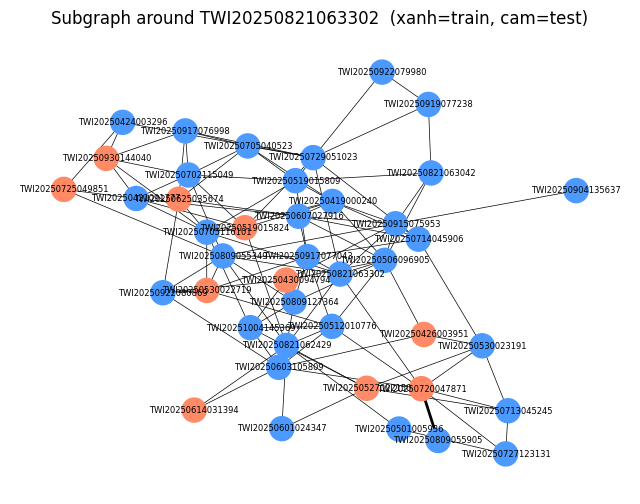

In [17]:
G_check = graph_cache[99]["graph_object"]
train_ids_99 = set(graph_cache[99]["train_meta"]["post_id"])
visualize_subgraph_sample(G_check, train_ids_99, save_path=RESULTS_DIR / "subgraph_check_seed99.png")

In [18]:
all_results = []

for seed in SEEDS:
    print("\n" + "=" * 70 + f"\nSEED {seed}\n" + "=" * 70)
    cache = graph_cache[seed]
    train_meta, test_meta = cache["train_meta"], cache["test_meta"]
    emb_df = cache["emb_df"]

    for variant_name, feat_df in cache["feature_sets"].items():
        tr, te = train_meta.copy(), test_meta.copy()
        if feat_df is not None:
            tr = tr.merge(feat_df, on="post_id", how="left")
            te = te.merge(feat_df, on="post_id", how="left")

        metrics, model, X_test = train_eval_variant(tr, te, seed=seed)
        metrics.update({"platform": PLATFORM, "variant": variant_name, "seed": seed})
        all_results.append(metrics)
        print(f"  [{variant_name:35s}] F1={metrics['f1']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

    feat_dd = cache["feature_sets"]["data_driven_homophily"]
    tr = train_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")
    te = test_meta.merge(feat_dd, on="post_id", how="left").merge(emb_df, on="post_id", how="left")

    variant_label = "data_driven_homophily+node2vec64"
    metrics, model, X_test = train_eval_variant(tr, te, seed=seed)
    metrics.update({"platform": PLATFORM, "variant": variant_label, "seed": seed})
    all_results.append(metrics)
    print(f"  [{variant_label:35s}] F1={metrics['f1']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

    sample = X_test.sample(min(500, len(X_test)), random_state=seed)
    shap_summary(model, sample, save_path=RESULTS_DIR / f"shap_{PLATFORM.lower()}_seed{seed}.png")

results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_comparison_raw.csv", index=False)


SEED 42
  [no_graph                           ] F1=0.6453  ROC-AUC=0.8887
  [unweighted_homophily               ] F1=0.6417  ROC-AUC=0.8894
  [similarity_knn                     ] F1=0.6293  ROC-AUC=0.8865
  [data_driven_homophily              ] F1=0.6462  ROC-AUC=0.8885
  [data_driven_homophily+node2vec64   ] F1=0.6460  ROC-AUC=0.8883


C:\Users\Admin\Documents\SNA-group7\Network_graph\graph_lib.py:190: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 123
  [no_graph                           ] F1=0.6212  ROC-AUC=0.8821
  [unweighted_homophily               ] F1=0.6135  ROC-AUC=0.8801
  [similarity_knn                     ] F1=0.6166  ROC-AUC=0.8838
  [data_driven_homophily              ] F1=0.6207  ROC-AUC=0.8811
  [data_driven_homophily+node2vec64   ] F1=0.6365  ROC-AUC=0.8837


C:\Users\Admin\Documents\SNA-group7\Network_graph\graph_lib.py:190: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 2024
  [no_graph                           ] F1=0.6339  ROC-AUC=0.8901
  [unweighted_homophily               ] F1=0.6293  ROC-AUC=0.8863
  [similarity_knn                     ] F1=0.6306  ROC-AUC=0.8902
  [data_driven_homophily              ] F1=0.6200  ROC-AUC=0.8874
  [data_driven_homophily+node2vec64   ] F1=0.6458  ROC-AUC=0.8890


C:\Users\Admin\Documents\SNA-group7\Network_graph\graph_lib.py:190: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 7
  [no_graph                           ] F1=0.6366  ROC-AUC=0.8888
  [unweighted_homophily               ] F1=0.6515  ROC-AUC=0.8904
  [similarity_knn                     ] F1=0.6320  ROC-AUC=0.8885
  [data_driven_homophily              ] F1=0.6410  ROC-AUC=0.8888
  [data_driven_homophily+node2vec64   ] F1=0.6468  ROC-AUC=0.8856


C:\Users\Admin\Documents\SNA-group7\Network_graph\graph_lib.py:190: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)



SEED 99
  [no_graph                           ] F1=0.6130  ROC-AUC=0.8837
  [unweighted_homophily               ] F1=0.6147  ROC-AUC=0.8835
  [similarity_knn                     ] F1=0.6191  ROC-AUC=0.8826
  [data_driven_homophily              ] F1=0.6268  ROC-AUC=0.8828
  [data_driven_homophily+node2vec64   ] F1=0.6269  ROC-AUC=0.8824


C:\Users\Admin\Documents\SNA-group7\Network_graph\graph_lib.py:190: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)


In [19]:
summary = results_df.groupby("variant")[["accuracy", "precision", "recall", "f1", "roc_auc"]].agg(["mean", "std"]).round(4)
print(summary)
summary.to_csv(RESULTS_DIR / f"{PLATFORM.lower()}_graph_comparison_summary.csv")

                                 accuracy         precision          recall  \
                                     mean     std      mean     std    mean   
variant                                                                       
data_driven_homophily              0.8253  0.0062    0.5492  0.0110  0.7414   
data_driven_homophily+node2vec64   0.8346  0.0040    0.5699  0.0100  0.7310   
no_graph                           0.8188  0.0035    0.5350  0.0106  0.7660   
similarity_knn                     0.8177  0.0027    0.5337  0.0079  0.7557   
unweighted_homophily               0.8245  0.0072    0.5477  0.0161  0.7420   

                                              f1         roc_auc          
                                     std    mean     std    mean     std  
variant                                                                   
data_driven_homophily             0.0154  0.6310  0.0120  0.8857  0.0035  
data_driven_homophily+node2vec64  0.0138  0.6404  0.0086  0.8858  0